# ¡Hola Diego! ¿Cómo estás? 🙂
<div class="alert alert-block alert-info">
   
Mi nombre es Andrés Barbosa 👋 

Un gusto conocerte, seré tu revisor en este proyecto.
A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:
Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y
corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para
mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.
Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más
precisa, junto con algunos ejemplos prácticos. También estoy abierto a responder cualquier duda que
tengas.
Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
Puedes encontrar mis comentarios en cuadros verdes, amarillos o rojos como este:
</div>
<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. Todo se ha hecho de forma correcta.
</div>
<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. Algunas recomendaciones o mejoras menores.
</div>
<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita arreglos. Este apartado requiere algunas correcciones. El trabajo no puede ser aceptado
con comentarios rojos.
</div>
<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:
Respuesta del estudiante.
</div>

Empecemos! 🚀 

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b> <a class="tocSkip"></a><br><br>

Hola, <b>Diego!</b><br><br>

Quiero felicitarte por el excelente trabajo realizado. Se observa un proyecto muy sólido desde el punto de vista metodológico, con un flujo de análisis ordenado y una clara orientación al problema de negocio planteado. Destaco especialmente la calidad del análisis exploratorio, donde no solo identificaste problemas de calidad de datos, sino que justificaste cada decisión tomada durante la limpieza y preparación de la información.

La construcción de métricas por operador está bien fundamentada y alineada con el objetivo de identificar operadores potencialmente ineficaces. También es destacable el uso de percentiles para definir criterios de clasificación, ya que la decisión surge directamente de las características observadas en los datos y no de umbrales arbitrarios. A lo largo del proyecto mantuviste una buena trazabilidad entre las observaciones obtenidas, las decisiones metodológicas adoptadas y las conclusiones finales.

Otro aspecto muy positivo es la sección de validación estadística. Las hipótesis están correctamente planteadas y la utilización de pruebas no paramétricas resulta adecuada considerando la distribución de las variables analizadas. Además, realizaste una interpretación crítica de los resultados, especialmente cuando la evidencia obtenida contradijo una de las hipótesis iniciales, mostrando una actitud analítica orientada a comprender el fenómeno en lugar de simplemente confirmar expectativas.

La presentación ejecutiva complementa muy bien el análisis técnico, resumiendo de forma clara el contexto del problema, la metodología aplicada y los principales hallazgos. Asimismo, el dashboard de Tableau constituye un excelente complemento visual para la comunicación de resultados, ya que permite explorar de manera intuitiva la distribución de operadores, los indicadores clave de desempeño y los hallazgos más relevantes del proyecto. La combinación de notebook, presentación y dashboard genera una entrega muy completa, cercana a un escenario real de análisis de datos para negocio.

En general, has desarrollado un proyecto bien estructurado, técnicamente correcto y con conclusiones accionables para la empresa. ¡Felicitaciones por el trabajo realizado y mucho éxito en los próximos proyectos!
</div>

Enlace de Google Drive: https://drive.google.com/drive/folders/13ySjsUq9rX3PLp_lOjokxaRFjr1NQKy6?usp=sharing

---
# 📊 Proyecto Final: Telecomunicaciones: identificar operadores ineficaces
---

## Descripción del proyecto

CallMeMaybe es un servicio de telefonía virtual que permite a las organizaciones gestionar grandes volúmenes de llamadas entrantes y salientes mediante equipos de operadores. Con el objetivo de mejorar la supervisión del desempeño, la empresa busca desarrollar una funcionalidad que permita identificar operadores potencialmente ineficaces.

En este proyecto se analizan los registros de llamadas de la plataforma para detectar patrones asociados a un bajo desempeño operativo. Para ello, se realiza un análisis exploratorio de datos, se construyen métricas por operador, se establecen criterios de clasificación mediante percentiles y se aplican pruebas de hipótesis estadísticas para validar los resultados obtenidos.

## Objetivo

Identificar operadores ineficaces a partir de indicadores como:

- Cantidad de llamadas perdidas.
- Tiempo promedio de espera de las llamadas entrantes.
- Volumen de llamadas salientes.

Los resultados permitirán proporcionar información útil a supervisores y supervisores para mejorar la gestión operativa y la calidad del servicio.

## Inicialización

In [1]:
# cargar todas las librerias necesarias para el proyecto

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu

## Paso 1. Descargar los datos

In [2]:
# Se carga el archivo de datos
telecom_dataset = pd.read_csv('/datasets/telecom_dataset_us.csv')
telecom_clients = pd.read_csv('/datasets/telecom_clients_us.csv')

## Paso 2. Llevar a cabo el análisis exploratorio de datos (EDA)

### 2.1 Dataframe **telecom_dataset**

In [3]:
# Vista general del dataframe telecom_dataset

print(telecom_dataset.shape)
print(telecom_dataset.head())
print()
telecom_dataset.info()
print()
print("Número de filas duplicadas:", telecom_dataset.duplicated().sum())
print()
print(telecom_dataset['direction'].unique())
print(telecom_dataset['internal'].unique())
print(telecom_dataset['is_missed_call'].unique())

print()
print(f"Número de datos nulos en la columna internal: {telecom_dataset['internal'].isnull().sum()}")
print(f"Número de datos nulos en la columna operador_id: {telecom_dataset['operator_id'].isnull().sum()}")


(53902, 9)
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
3   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
4   166377  2019-08-05 00:00:00+03:00       out    False     880022.0   

   is_missed_call  calls_count  call_duration  total_call_duration  
0            True            2              0                    4  
1            True            3              0                    5  
2            True            1              0                    1  
3           False            1             10                   18  
4            True            3              0                   25  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               N

### 2.1.1 Observaciones dataframe **telecom_dataset**

 - El dataframe tiene 53902 filas y 9 columnas
 - user_id es de tipo entero, se tiene que convertir a tipo object
 - El tipo de dato de la fecha es incorrecto, se tiene que convertir a tipo fecha
 - operator_id es flotante, se tiene que convertir a tipo object
 - Se identificaron 4900 filas duplicadas (9.1% del dataset). Debido a que representan una proporción considerable de los registros y podrían corresponder a eventos válidos de llamadas, se realizará un análisis adicional antes de decidir su eliminación.
 - Se detectaron 117 valores ausentes en la columna internal (0.22% del dataset). Debido a su baja proporción, estos registros podrán eliminarse o clasificarse como categoría desconocida sin afectar significativamente el análisis.
 - Se encontraron 8172 valores ausentes en la columna operator_id (15.2% del dataset). Antes de imputar o eliminar estos registros se analizará si corresponden a llamadas no asignadas a operadores, ya que podrían ser relevantes para la identificación de operadores ineficaces.

### 2.1.2 Corregir datos del dataframe **telecom_dataset**

In [4]:
# Convertir user_id a tipo object
telecom_dataset['user_id'] = telecom_dataset['user_id'].astype('object')


# Convertir date a tipo fecha
telecom_dataset['date'] = pd.to_datetime(telecom_dataset['date'])

# Convertir operador_id a tipo object (primero se convierte a entero para corregir formato decimal)
telecom_dataset['operator_id'] = (telecom_dataset['operator_id'].astype('Int64').astype('object'))

#telecom_dataset.info()
#print(telecom_dataset.head())

# Crear un dataframe de puro duplicado para analizarlo aparte
duplicates = telecom_dataset[
    telecom_dataset.duplicated(keep=False)
]

duplicates.head(20)

# Agrupar los registros duplicados por todas las columnas para verificar
# cuántas veces se repite cada combinación exacta de valores.

duplicates.groupby(
    telecom_dataset.columns.tolist()
).size().sort_values(ascending=False)


user_id  date                       direction  internal  operator_id  is_missed_call  calls_count  call_duration  total_call_duration
166377   2019-08-05 00:00:00+03:00  out        False     880020       True            8            0              50                     2
167626   2019-09-27 00:00:00+03:00  out        False     919910       True            14           0              278                    2
         2019-09-28 00:00:00+03:00  out        False     920416       False           39           1519           2269                   2
                                                         921592       False           85           4333           5953                   2
                                                         921596       False           68           4712           6181                   2
                                                                                                                                        ..
166974   2019-11-06 00:00:00+03:

### Observaciones

 - Todo indica que los duplicados son exactos, el valor final 2 indica que esa combinación completa de las 9 columnas aparece exactamente dos veces.
 - Length: 4179 significa que existen 4179 combinaciones únicas duplicadas, cada una repetida dos veces, lo que explica aproximadamente los 4900 registros duplicados encontrados.
- En conclusión podemos borrar los duplicados debido a:
    - Son duplicados completos.
    - No contienen información adicional.
    - Mantenerlos inflaría artificialmente:
        - el número de llamadas,
        - la duración total,
        - el tiempo de espera,
        - las llamadas perdidas.
          
Esto podría llevar a clasificar incorrectamente a un operador como ineficaz.
   

### 2.1.3 Eliminar duplicados

In [5]:
# Eliminar duplicados
telecom_dataset = telecom_dataset.drop_duplicates().reset_index(drop=True)

#telecom_dataset.info()
#print(telecom_dataset.head())
print("Número de filas duplicadas:", telecom_dataset.duplicated().sum())
print()
print(f"Número de datos nulos en la columna internal: {telecom_dataset['internal'].isnull().sum()}")
print(f"Número de datos nulos en la columna operador_id: {telecom_dataset['operator_id'].isnull().sum()}")



Número de filas duplicadas: 0

Número de datos nulos en la columna internal: 110
Número de datos nulos en la columna operador_id: 7456


In [6]:

# Distribución de operator_id nulo
print(
    telecom_dataset[
        telecom_dataset['operator_id'].isna()
    ][['direction','is_missed_call']]
    .value_counts()
)

# Distribución de internal nulo
print(
    telecom_dataset[
        telecom_dataset['internal'].isna()
    ][['direction','is_missed_call']]
    .value_counts()
)


direction  is_missed_call
in         True              7202
out        True               141
in         False               68
out        False               45
dtype: int64
direction  is_missed_call
in         False             54
           True              54
out        True               2
dtype: int64


### Observaciones

1. Valores nulos en **operator_id**
Se identificaron 7456 valores ausentes en la columna operator_id, lo que representa aproximadamente:
7456 / 53902 * 100

≈ 13.8% del dataset

La distribución de estos registros muestra que la gran mayoría corresponde a llamadas entrantes (in) y perdidas (is_missed_call = True).
En menor proporción aparecen llamadas salientes y no perdidas, pero son casos marginales.

📌 Esto sugiere que los valores nulos en operator_id no son aleatorios, sino que están asociados principalmente a **llamadas entrantes que no fueron atendidas** y, por lo tanto, no se asignó un operador.

2. Valores nulos en **internal**
Se detectaron 110 valores ausentes en internal, lo que representa aproximadamente:
110 / 53902 * 100

≈ 0.20% del dataset

Estos registros se distribuyen entre llamadas entrantes y salientes, tanto perdidas como no perdidas.
No se observa un patrón claro que relacione los valores nulos con algún tipo específico de llamada.

📌 Debido a su muy baja proporción, estos valores **no representan un problema significativo para el análisis y pueden eliminarse** o imputarse sin afectar los resultados.

### 2.1.4 Eliminar valores nulos de la columna internal

In [7]:
# Eliminar valores nulos en la columna internal
telecom_dataset = telecom_dataset.dropna(subset=['internal']).reset_index(drop=True)

# Verificar
print(telecom_dataset['internal'].isna().sum())

# Se conservan los valores nulos en operator_id porque representan llamadas entrantes no atendidas,
# las cuales no fueron asignadas a ningún operador y son relevantes para el análisis de eficiencia.

telecom_dataset['operator_id'].isna().sum()

0


7401

### 2.2 Dataframe **telecom_clients**

In [8]:
# Vista general del dataframe telecom_clients

print(telecom_clients.shape)
print(telecom_clients.head())
print()
telecom_clients.info()
print()
print("Número de filas duplicadas:", telecom_clients.duplicated().sum())
print()
print(telecom_clients['tariff_plan'].unique())

(732, 3)
   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB

Número de filas duplicadas: 0

['A' 'C' 'B']


### 2.2.1 Observaciones dataframe **telecom_clients**
 - Existen 732 filas y 3 columnas en el dataframe
 - user_id es de tipo entero, se tiene que convertir a tipo object
 - date_start es tipo object, se tiene que cambiar a tipo fecha
 - No hay filas duplicadas
 - No hay datos nulos

### 2.2.2 Corregir datos del dataframe **telecom_clients**

In [9]:
# Convertir user_id a tipo object
telecom_clients['user_id'] = telecom_clients['user_id'].astype('object')

# Convertir date_start a tipo fecha
telecom_clients['date_start'] = pd.to_datetime(telecom_clients['date_start'])

telecom_clients.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    object        
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 17.3+ KB


### Conclusiones del Análisis Exploratorio de Datos

 - El conjunto de datos principal contiene información de las llamadas realizadas y recibidas por los operadores de los clientes de CallMeMaybe, con un total inicial de 53902 registros y 9 variables.
 - Se realizaron las conversiones necesarias de tipos de datos para facilitar el análisis. Las columnas user_id y operator_id se trataron como identificadores y se convirtieron a tipo objeto, mientras que la columna date se convirtió a tipo datetime.
 - Se identificaron 4900 registros duplicados, equivalentes al 9.1 % del conjunto de datos. El análisis mostró que correspondían a duplicados exactos, por lo que fueron eliminados para evitar distorsiones en las métricas de llamadas, duración y tiempos de espera.
 - Se detectaron 110 valores ausentes en la columna internal, que representan aproximadamente el 0.2 % del conjunto de datos. Debido a su baja proporción y a la ausencia de un patrón evidente, estos registros fueron eliminados sin afectar significativamente el análisis.
 - Se encontraron 7456 valores ausentes en operator_id, equivalentes al 13.8 % de los registros. La mayoría de estos casos corresponden a llamadas entrantes perdidas, por lo que se decidió conservarlos inicialmente, ya que su ausencia parece estar asociada a llamadas que nunca fueron asignadas a un operador y no a errores de captura.
 - El dataframe telecom_clients no presentó registros duplicados ni valores ausentes. Sus variables podrán utilizarse posteriormente para enriquecer el análisis mediante la incorporación de información sobre los clientes y sus planes tarifarios.
 - Después del proceso de limpieza, el conjunto de datos presenta una estructura consistente y adecuada para identificar operadores ineficaces y realizar las pruebas estadísticas correspondientes.

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b><br>

Excelente trabajo en la etapa de análisis exploratorio y limpieza de datos. Realizaste una revisión exhaustiva de la estructura de ambos conjuntos de datos, identificando correctamente problemas de tipos de datos, valores ausentes y registros duplicados. Destaco especialmente el análisis realizado sobre los duplicados, ya que no te limitaste a eliminarlos automáticamente, sino que verificaste previamente que se trataba de registros completamente idénticos y justificaste adecuadamente su eliminación.

También es muy positivo el estudio de los valores nulos en <code>operator_id</code>, donde analizaste su distribución antes de tomar una decisión. La conclusión de conservar estos registros debido a su posible relación con llamadas perdidas no asignadas está bien fundamentada y demuestra una comprensión adecuada del contexto de negocio. Finalmente, las conclusiones sintetizan de forma clara las principales transformaciones realizadas y dejan preparado el conjunto de datos para las siguientes etapas del proyecto.
</div>

## Paso 3. Identificar operadores ineficaces

### 3.1 Integración de los conjuntos de datos

In [10]:
# Fusionar ambos conjuntos de datos para centralizar la información
# de llamadas y clientes en un único dataframe para el análisis.

telecom = telecom_dataset.merge(
    telecom_clients,
    on='user_id',
    how='left'
)

# Verificar
print(telecom.head())
print()
print(telecom.shape)
print(telecom.isnull().sum())

  user_id                      date direction internal operator_id  \
0  166377 2019-08-04 00:00:00+03:00        in    False        <NA>   
1  166377 2019-08-05 00:00:00+03:00       out     True      880022   
2  166377 2019-08-05 00:00:00+03:00       out     True      880020   
3  166377 2019-08-05 00:00:00+03:00       out     True      880020   
4  166377 2019-08-05 00:00:00+03:00       out    False      880022   

   is_missed_call  calls_count  call_duration  total_call_duration  \
0            True            2              0                    4   
1            True            3              0                    5   
2            True            1              0                    1   
3           False            1             10                   18   
4            True            3              0                   25   

  tariff_plan date_start  
0           B 2019-08-01  
1           B 2019-08-01  
2           B 2019-08-01  
3           B 2019-08-01  
4           B 2019-08-0

### 3.2 Trabajar únicamente con registros asociados a operadores

In [11]:
# Creamos un nuevo dataframe sin tomar en cuenta los operadores nulos
telecom_operators = telecom.dropna(subset=['operator_id']).copy()

# Verificar
telecom_operators.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41491 entries, 1 to 48890
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              41491 non-null  object                               
 1   date                 41491 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            41491 non-null  object                               
 3   internal             41491 non-null  object                               
 4   operator_id          41491 non-null  object                               
 5   is_missed_call       41491 non-null  bool                                 
 6   calls_count          41491 non-null  int64                                
 7   call_duration        41491 non-null  int64                                
 8   total_call_duration  41491 non-null  int64                                
 9   tariff

### 3.3 Calcular el tiempo de espera


count    41491.000000
mean       312.213227
std       1176.102940
min          0.000000
25%         19.000000
50%         60.000000
75%        219.000000
max      46474.000000
Name: waiting_time, dtype: float64


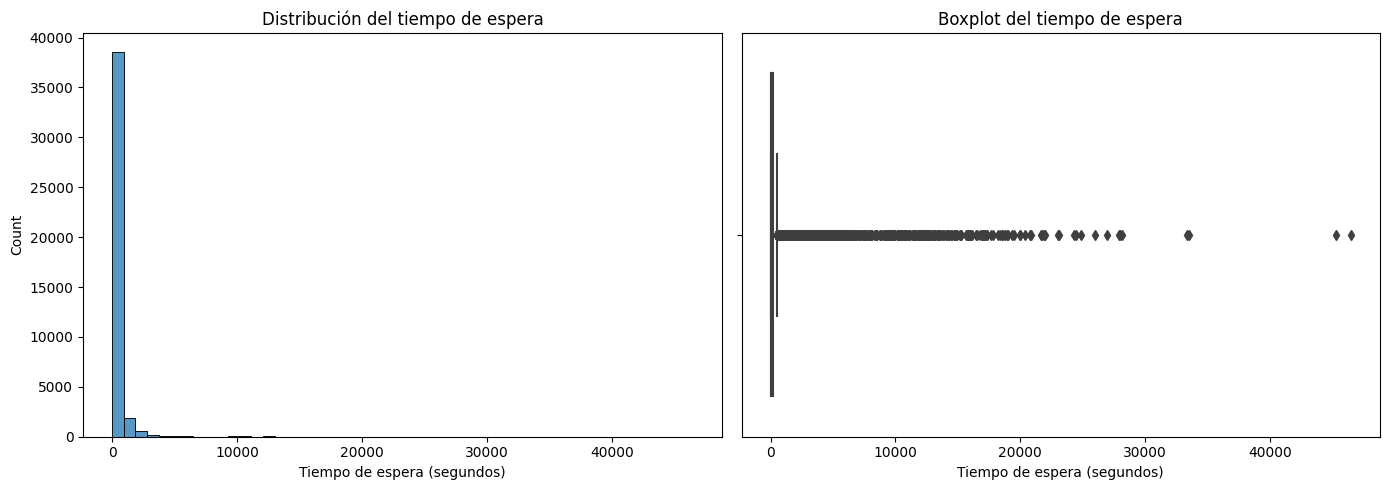

In [12]:
# Calcular el tiempo de espera de cada llamada como la diferencia entre
# la duración total de la llamada y la duración efectiva de la conversación.

telecom_operators['waiting_time'] = (
    telecom_operators['total_call_duration']
    - telecom_operators['call_duration']
)

# Obtener estadísticas descriptivas para comprender la distribución
# del tiempo de espera y detectar posibles valores atípicos.
print()
print(telecom_operators['waiting_time'].describe())


# Visualizar la distribución del tiempo de espera mediante un histograma
# y un boxplot para identificar asimetrías y valores extremos.

plt.figure(figsize=(14,5))

# Histograma
plt.subplot(1,2,1)
sns.histplot(
    telecom_operators['waiting_time'],
    bins=50
)
plt.title('Distribución del tiempo de espera')
plt.xlabel('Tiempo de espera (segundos)')

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(
    x=telecom_operators['waiting_time']
)
plt.title('Boxplot del tiempo de espera')
plt.xlabel('Tiempo de espera (segundos)')

plt.tight_layout()
plt.show()



### Distribución del tiempo de espera

La distribución del tiempo de espera presenta una fuerte asimetría positiva. La mayor parte de las llamadas tienen tiempos de espera relativamente bajos, aunque existen registros con tiempos considerablemente más altos, lo que genera una larga cola hacia la derecha.

El boxplot muestra una gran cantidad de valores atípicos y algunos tiempos de espera extremadamente elevados, cercanos a las 13 horas. Debido a que el objetivo del proyecto es identificar operadores ineficaces, estos valores no se consideran errores de forma inmediata, ya que podrían reflejar un desempeño deficiente y aportar información relevante para el análisis.

### 3.3.1 Análisis del tiempo en espera con percentiles

count    41491.000000
mean       312.213227
std       1176.102940
min          0.000000
50%         60.000000
90%        659.000000
95%       1234.500000
99%       3495.400000
max      46474.000000
Name: waiting_time, dtype: float64


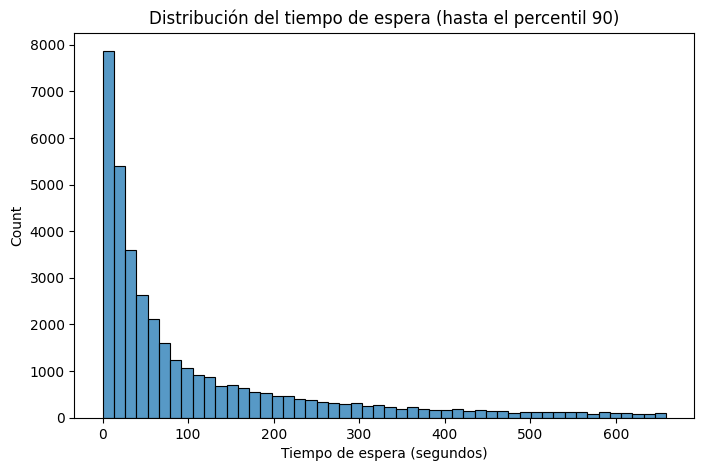

In [13]:
# Calcular percentiles altos del tiempo de espera para identificar valores
# excepcionalmente elevados que podrían estar asociados a operadores ineficaces.

print(
    telecom_operators['waiting_time']
    .describe(percentiles=[.90, .95, .99])
)


# Visualizar la distribución principal del tiempo de espera limitando la gráfica
# al percentil 90 para reducir el efecto de los valores extremos y apreciar
# con mayor claridad el comportamiento de la mayoría de las observaciones.


limit = telecom_operators['waiting_time'].quantile(.90)

plt.figure(figsize=(8,5))

sns.histplot(
    telecom_operators.loc[
        telecom_operators['waiting_time'] <= limit,
        'waiting_time'
    ],
    bins=50
)

plt.title('Distribución del tiempo de espera (hasta el percentil 90)')
plt.xlabel('Tiempo de espera (segundos)')

plt.show()


### Distribución del tiempo de espera
 - El tiempo de espera presenta una distribución fuertemente sesgada hacia la derecha.
 - La mayoría de las llamadas tienen tiempos de espera relativamente bajos, concentrándose principalmente en los primeros minutos.
 - Conforme aumenta el tiempo de espera, la frecuencia de llamadas disminuye gradualmente, generando una cola larga.
 - Debido a la presencia de valores extremadamente altos, la visualización se limitó al percentil 90 con el objetivo de apreciar mejor la distribución principal de los datos.
 - Los valores extremos no fueron eliminados, ya que podrían representar comportamientos asociados a operadores ineficaces y, por tanto, contienen información relevante para el análisis.

### 3.4 Construir métricas por operador

In [14]:
# Crear un resumen por operador
# total_calls se descarta debido a que se requiere de un cálculo
operator_metrics = (
    telecom_operators
    .groupby('operator_id')
    .agg(
        #total_calls=('calls_count', 'sum'),
        missed_calls=('is_missed_call', 'sum'),
        incoming_calls=('direction', lambda x: (x == 'in').sum()),
        outgoing_calls=('direction', lambda x: (x == 'out').sum()),
        avg_waiting_time=('waiting_time', 'mean'),
        median_waiting_time=('waiting_time', 'median')
    )
    .reset_index()
)

# Calcular el total de llamadas en la columna total_interactions
operator_metrics['total_interactions'] = (
    operator_metrics['incoming_calls']
    + operator_metrics['outgoing_calls']
)
operator_metrics




,operator_id,missed_calls,incoming_calls,outgoing_calls,avg_waiting_time,median_waiting_time,total_interactions
0,879896,47,21,96,104.914530,27.0,117
1,879898,89,56,170,459.690265,393.0,226
2,880020,6,7,13,14.000000,8.0,20
3,880022,29,8,62,53.971429,13.0,70
4,880026,87,18,164,121.978022,112.0,182
...,...,...,...,...,...,...,...
1087,972410,2,0,4,374.500000,246.5,4
1088,972412,2,1,4,210.000000,228.0,5
1089,972460,3,1,6,88.571429,65.0,7
1090,973120,1,0,2,10.000000,10.0,2


### 3.4.1 Estadisticas descriptivas

In [15]:
# Obtener estadísticas descriptivas de las métricas por operador
operator_metrics.describe().T

,count,mean,std,min,25%,50%,75%,max
operator_id,1092.0,925517.543956,22854.532209,879896.0,906393.500,925105.000000,944211.500000,973286.000000
missed_calls,1092.0,12.920330,18.393800,0.0,1.000,5.000000,18.000000,119.000000
incoming_calls,1092.0,11.609890,18.100944,0.0,0.000,3.000000,15.000000,107.000000
outgoing_calls,1092.0,26.385531,36.618762,0.0,1.000,10.000000,39.000000,228.000000
avg_waiting_time,1092.0,216.249892,507.052815,0.0,23.000,46.619048,159.758929,5805.027397
median_waiting_time,1092.0,181.666209,420.965171,0.0,16.875,32.000000,104.625000,4525.000000
total_interactions,1092.0,37.995421,49.141679,1.0,5.000,19.000000,50.000000,323.000000


### Conclusión

Las estadísticas descriptivas muestran una alta variabilidad en el desempeño de los operadores. La mitad de los operadores registra 5 o menos llamadas perdidas, mientras que el 25% con peor desempeño supera las 18 llamadas perdidas. De manera similar, el tiempo promedio de espera presenta una distribución muy dispersa, con una mediana de 46.6 segundos y valores máximos que superan los 5,800 segundos.

Las diferencias observadas entre la media y la mediana, especialmente en las métricas de tiempo de espera, sugieren la presencia de valores atípicos y distribuciones asimétricas. Por esta razón, los percentiles resultan más apropiados que la media para establecer umbrales de clasificación.

A partir de estos resultados, se utilizarán el percentil 75 de las llamadas perdidas y del tiempo de espera, así como el percentil 25 de las llamadas salientes, para identificar operadores que presenten señales de ineficacia.


### 3.4.2 Visualización de las distribuciones

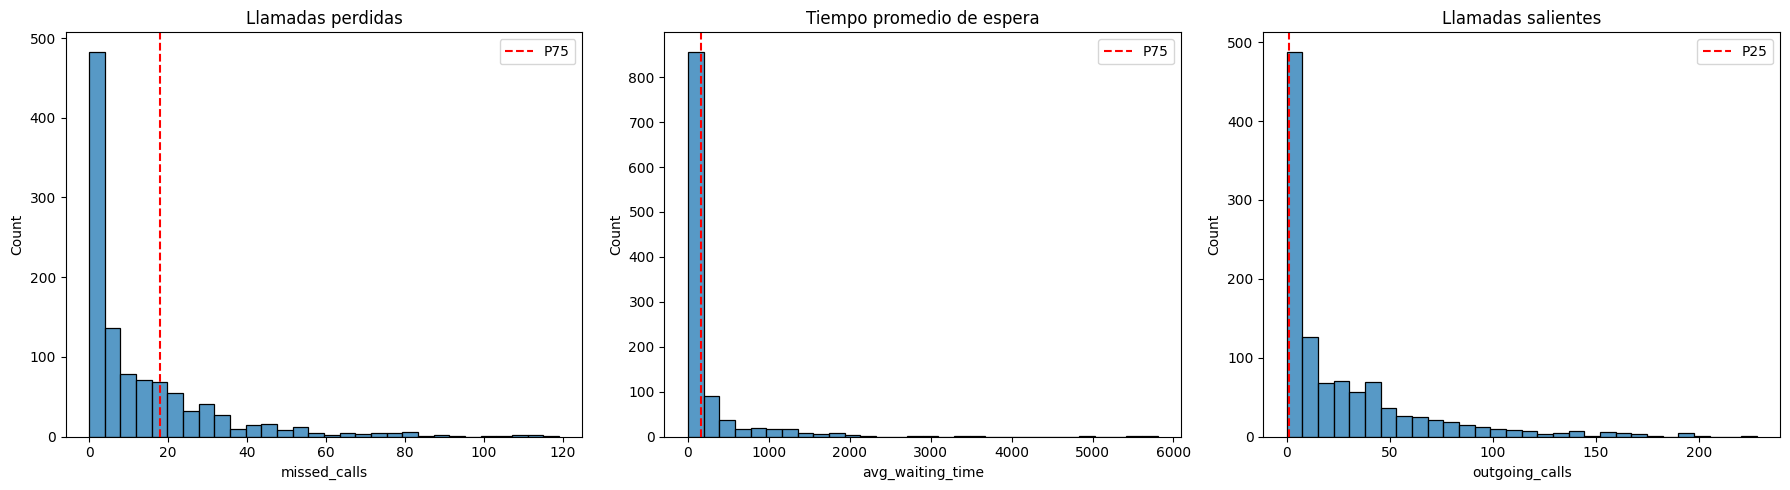

In [16]:

# Analizar la distribución de llamadas perdidas, tiempo de espera y llamadas
# salientes para establecer criterios de clasificación de operadores ineficaces.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(operator_metrics['missed_calls'], bins=30, ax=axes[0])
axes[0].axvline(
    operator_metrics['missed_calls'].quantile(0.75),
    color='red',
    linestyle='--',
    label='P75'
)
axes[0].set_title('Llamadas perdidas')
axes[0].legend()

sns.histplot(operator_metrics['avg_waiting_time'], bins=30, ax=axes[1])
axes[1].axvline(
    operator_metrics['avg_waiting_time'].quantile(0.75),
    color='red',
    linestyle='--',
    label='P75'
)
axes[1].set_title('Tiempo promedio de espera')
axes[1].legend()

sns.histplot(operator_metrics['outgoing_calls'], bins=30, ax=axes[2])
axes[2].axvline(
    operator_metrics['outgoing_calls'].quantile(0.25),
    color='red',
    linestyle='--',
    label='P25'
)
axes[2].set_title('Llamadas salientes')
axes[2].legend()

plt.tight_layout()
plt.show()



### 3.5 Definir umbrales

In [17]:
# Definir umbrales utilizando percentiles para identificar valores extremos.
# Se utiliza el percentil 75 para llamadas perdidas y tiempo de espera,
# y el percentil 25 para llamadas salientes.

missed_threshold = operator_metrics['missed_calls'].quantile(0.75)
waiting_threshold = operator_metrics['avg_waiting_time'].quantile(0.75)
outgoing_threshold = operator_metrics['outgoing_calls'].quantile(0.25)

print('Missed calls P75:', missed_threshold)
print('Waiting time P75:', waiting_threshold)
print('Outgoing calls P25:', outgoing_threshold)


# Crear un sistema de puntuación para medir la ineficacia de cada operador.
# Cada criterio incumplido suma 1 punto al score.

operator_metrics['score'] = 0

operator_metrics.loc[
    operator_metrics['missed_calls'] > missed_threshold,
    'score'
] += 1

operator_metrics.loc[
    operator_metrics['avg_waiting_time'] > waiting_threshold,
    'score'
] += 1

operator_metrics.loc[
    operator_metrics['outgoing_calls'] < outgoing_threshold,
    'score'
] += 1

operator_metrics[['operator_id','score']].head()


Missed calls P75: 18.0
Waiting time P75: 159.75892857142856
Outgoing calls P25: 1.0


,operator_id,score
0,879896,1
1,879898,2
2,880020,0
3,880022,1
4,880026,1


### Conclusión

Se establecieron umbrales de referencia utilizando percentiles para identificar comportamientos extremos en las principales métricas de desempeño. Los resultados indican que un operador presenta una cantidad elevada de llamadas perdidas cuando supera las 18 llamadas, un tiempo de espera elevado cuando excede los 159.76 segundos en promedio y una baja actividad en llamadas salientes cuando se encuentra por debajo del percentil 25.

Con base en estos criterios, se implementó un sistema de puntuación en el que cada operador recibe un punto por cada condición desfavorable que cumple. Este enfoque permite evaluar el desempeño de manera integral y facilita la identificación de operadores con múltiples señales de ineficacia. En la siguiente etapa se analizará la distribución de las puntuaciones obtenidas para definir qué operadores serán clasificados como ineficaces.


### 3.6 Identificación de operadores ineficaces

0    465
1    499
2    128
Name: score, dtype: int64



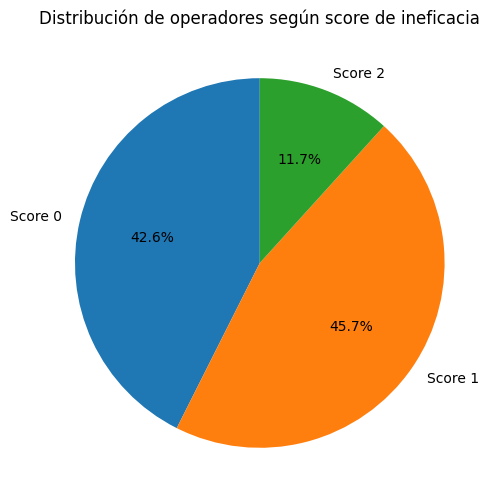

In [18]:
# Analizar cuántos operadores cumplen 0, 1, 2 o 3 criterios de ineficacia.
# Esto permite evaluar la distribución del sistema de puntuación.

print(operator_metrics['score'].value_counts().sort_index())
print()

# Obtener la distribución de frecuencias de las puntuaciones asignadas
# a los operadores.

score_distribution = (
    operator_metrics['score']
    .value_counts()
    .sort_index()
)

score_distribution = (
    operator_metrics['score']
    .value_counts()
    .sort_index()
)


# Visualizar la proporción de operadores en cada categoría de score
# mediante un diagrama de pastel.

plt.figure(figsize=(6, 6))

plt.pie(
    score_distribution,
    labels=[f'Score {i}' for i in score_distribution.index],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribución de operadores según score de ineficacia')

plt.show()

### Conclusión

La distribución de las puntuaciones muestra que la mayoría de los operadores presenta un desempeño aceptable o únicamente una señal aislada de ineficacia. En particular, el 42.6% de los operadores no cumple ningún criterio de ineficacia (score = 0), mientras que el 45.7% cumple únicamente uno de los criterios evaluados (score = 1).

Por otro lado, el 11.7% de los operadores obtiene una puntuación de 2, lo que indica que presentan simultáneamente múltiples señales de desempeño deficiente, como un elevado número de llamadas perdidas, tiempos de espera prolongados o una baja actividad en llamadas salientes. No se identificaron operadores con una puntuación de 3.

Dado que los operadores con score = 2 concentran más de una señal de ineficacia, se consideran candidatos adecuados para ser clasificados como operadores ineficaces. En consecuencia, para las siguientes etapas del análisis se utilizará el criterio score ≥ 2, identificando a 128 operadores que requieren una evaluación más detallada.

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b><br>

Muy buen desarrollo de esta sección. La construcción de las métricas está bien alineada con el objetivo de negocio y se observa una secuencia lógica de trabajo: integración de datos, selección de registros relevantes, creación de variables derivadas y consolidación de indicadores por operador. Destaco especialmente la creación y análisis del tiempo de espera, ya que no solo calculaste la métrica, sino que también exploraste su distribución mediante estadísticas descriptivas, histogramas y percentiles antes de utilizarla para la clasificación de operadores.

También es acertada la decisión de conservar los valores extremos tras evaluar su posible significado dentro del contexto del problema, evitando eliminarlos automáticamente sin justificación. La construcción de métricas agregadas por operador resulta clara y permite comparar distintos aspectos del desempeño operativo. Finalmente, la elección de percentiles para establecer umbrales está correctamente fundamentada a partir de la fuerte asimetría observada en las distribuciones, lo que demuestra un buen criterio analítico para la identificación de operadores potencialmente ineficaces.
</div>

## Paso 4. Probar hipotesis estadisticas

Las distribuciones de las métricas presentan asimetrías y valores extremos, por lo que no se asumió normalidad. En consecuencia, se utilizarán pruebas no paramétricas de Mann-Whitney para comparar los grupos.

### 4.1 Formulación de hipótesis

### 4.1.1 Hipótesis 1
 - H₀: El tiempo promedio de espera es igual entre operadores eficientes e ineficaces.
 - H₁: Los operadores ineficaces presentan tiempos promedio de espera mayores.

In [19]:

# Separar los tiempos promedio de espera de los operadores eficientes
# (score = 0) y de los operadores ineficaces (score ≥ 2).

efficient_wait = (
    operator_metrics.loc[
        operator_metrics['score'] == 0,
        'avg_waiting_time'
    ]
)

inefficient_wait = (
    operator_metrics.loc[
        operator_metrics['score'] >= 2,
        'avg_waiting_time'
    ]
)

# Aplicar la prueba no paramétrica de Mann-Whitney para determinar
# si los operadores ineficaces presentan tiempos promedio de espera
# significativamente mayores que los operadores eficientes.

results = mannwhitneyu(
    inefficient_wait,
    efficient_wait,
    alternative='greater'
)

# Definir el nivel de significancia para la prueba estadística.
alpha = 0.05

print('p-value:', results.pvalue)
print()

# Interpretar el valor p y determinar si existe evidencia estadística
# para rechazar la hipótesis nula.

if results.pvalue < alpha:
    print(f'Como el valor p ({results.pvalue:.2e}) es menor que α = {alpha}, se rechaza la hipótesis nula.')
    print('Existe evidencia estadística suficiente para concluir que los operadores ineficaces (score ≥ 2) presentan tiempos promedio de espera significativamente mayores que los operadores eficientes (score = 0).')
else:
    print(f'Como el valor p ({results.pvalue:.2e}) es mayor o igual que α = {alpha}, no se puede rechazar la hipótesis nula.')
    print('No existe evidencia estadística suficiente para concluir que los operadores ineficaces presentan tiempos promedio de espera significativamente mayores que los operadores eficientes.')


p-value: 1.220523410101164e-67

Como el valor p (1.22e-67) es menor que α = 0.05, se rechaza la hipótesis nula.
Existe evidencia estadística suficiente para concluir que los operadores ineficaces (score ≥ 2) presentan tiempos promedio de espera significativamente mayores que los operadores eficientes (score = 0).


### 4.1.2 Hipótesis 2
 - H₀: La cantidad de llamadas perdidas es igual entre operadores eficientes e ineficaces.
 - H₁: Los operadores ineficaces presentan una mayor cantidad de llamadas perdidas.

In [20]:
# Separar la cantidad de llamadas perdidas de los operadores eficientes
# (score = 0) y de los operadores ineficaces (score ≥ 2).

efficient_missed = (
    operator_metrics.loc[
        operator_metrics['score'] == 0,
        'missed_calls'
    ]
)

inefficient_missed = (
    operator_metrics.loc[
        operator_metrics['score'] >= 2,
        'missed_calls'
    ]
)

# Aplicar la prueba no paramétrica de Mann-Whitney para determinar
# si los operadores ineficaces presentan una cantidad de llamadas
# perdidas significativamente mayor que los operadores eficientes.

results = mannwhitneyu(
    inefficient_missed,
    efficient_missed,
    alternative='greater'
)

# Definir el nivel de significancia para la prueba estadística.
alpha = 0.05

print('p-value:', results.pvalue)


# Interpretar el valor p y determinar si existe evidencia estadística
# para rechazar la hipótesis nula.

if results.pvalue < alpha:
    print(
        f'Como el valor p ({results.pvalue:.2e}) es menor que α = {alpha}, '
        'se rechaza la hipótesis nula.'
    )
    print(
        'Existe evidencia estadística suficiente para concluir que los '
        'operadores ineficaces (score ≥ 2) presentan una cantidad de '
        'llamadas perdidas significativamente mayor que los operadores '
        'eficientes (score = 0).'
    )
else:
    print(
        f'Como el valor p ({results.pvalue:.2e}) es mayor o igual que α = {alpha}, '
        'no se puede rechazar la hipótesis nula.'
    )
    print(
        'No existe evidencia estadística suficiente para concluir que los '
        'operadores ineficaces presentan una cantidad de llamadas perdidas '
        'significativamente mayor que los operadores eficientes.'
    )

p-value: 3.4339171303927433e-66
Como el valor p (3.43e-66) es menor que α = 0.05, se rechaza la hipótesis nula.
Existe evidencia estadística suficiente para concluir que los operadores ineficaces (score ≥ 2) presentan una cantidad de llamadas perdidas significativamente mayor que los operadores eficientes (score = 0).


### 4.1.3 Hipótesis 3
 - H₀: La cantidad de llamadas salientes es igual entre operadores eficientes e ineficaces.
 - H₁: Los operadores ineficaces presentan una menor cantidad de llamadas salientes que los operadores eficientes.

In [21]:
# Separar la cantidad de llamadas salientes de los operadores eficientes
# (score = 0) y de los operadores ineficaces (score ≥ 2).

efficient_outgoing = (
    operator_metrics.loc[
        operator_metrics['score'] == 0,
        'outgoing_calls'
    ]
)

inefficient_outgoing = (
    operator_metrics.loc[
        operator_metrics['score'] >= 2,
        'outgoing_calls'
    ]
)

# Aplicar la prueba no paramétrica de Mann-Whitney para determinar
# si los operadores ineficaces presentan una cantidad de llamadas
# salientes significativamente menor que los operadores eficientes.

results = mannwhitneyu(
    inefficient_outgoing,
    efficient_outgoing,
    alternative='less'
)

# Definir el nivel de significancia para la prueba estadística.
alpha = 0.05

# Interpretar el valor p y determinar si existe evidencia estadística
# para rechazar la hipótesis nula.
print('p-value:', results.pvalue)
print()

if results.pvalue < alpha:
    print(f'Como el valor p ({results.pvalue:.2e}) es menor que α = {alpha}, se rechaza la hipótesis nula.')
    print('Existe evidencia estadística suficiente para concluir que los operadores ineficaces (score ≥ 2) presentan una cantidad de llamadas salientes significativamente menor que los operadores eficientes (score = 0).')
else:
    print(f'Como el valor p ({results.pvalue:.2e}) es mayor o igual que α = {alpha}, no se puede rechazar la hipótesis nula.')
    print('No existe evidencia estadística suficiente para concluir que los operadores ineficaces presentan una cantidad de llamadas salientes significativamente menor que los operadores eficientes.')


p-value: 1.0

Como el valor p (1.00e+00) es mayor o igual que α = 0.05, no se puede rechazar la hipótesis nula.
No existe evidencia estadística suficiente para concluir que los operadores ineficaces presentan una cantidad de llamadas salientes significativamente menor que los operadores eficientes.


In [22]:
# Analizar la distribución de llamadas salientes en ambos grupos
# para verificar si los operadores ineficaces realmente realizan
# menos llamadas salientes que los operadores eficientes.

print("Eficientes:")
print(efficient_outgoing.describe())
print("\nIneficaces:")
print(inefficient_outgoing.describe())

Eficientes:
count    465.000000
mean      10.892473
std       11.760599
min        1.000000
25%        2.000000
50%        6.000000
75%       17.000000
max       72.000000
Name: outgoing_calls, dtype: float64

Ineficaces:
count    128.000000
mean      70.835938
std       37.687229
min        0.000000
25%       44.000000
50%       60.000000
75%       87.250000
max      194.000000
Name: outgoing_calls, dtype: float64


### Interpretación de las estadísticas descriptivas

Las estadísticas descriptivas muestran que los operadores ineficaces realizan, en promedio, un mayor número de llamadas salientes que los operadores eficientes. Mientras que los operadores eficientes registran una media de 10.9 llamadas salientes, los operadores ineficaces alcanzan una media de 70.8 llamadas.

Este resultado explica por qué la tercera hipótesis no fue respaldada por la prueba estadística. La clasificación de operadores ineficaces se basa en la combinación de múltiples criterios, por lo que un operador puede ser considerado ineficaz debido a un elevado número de llamadas perdidas y tiempos de espera prolongados, sin necesariamente presentar un bajo volumen de llamadas salientes.

Por lo tanto, la cantidad de llamadas salientes no parece ser un indicador adecuado de ineficacia en este conjunto de datos.

# Paso 5. Conclusiones finales

El objetivo de este proyecto fue identificar operadores ineficaces dentro del servicio de telefonía virtual CallMeMaybe mediante el análisis de métricas operativas y la validación de hipótesis estadísticas.

Durante el análisis exploratorio se observó una alta variabilidad en el desempeño de los operadores. Las distribuciones de llamadas perdidas, tiempo de espera y llamadas salientes presentaron asimetrías y valores extremos, por lo que se utilizaron percentiles para establecer criterios objetivos de clasificación.

A partir de las métricas construidas por operador, se definió un sistema de puntuación basado en tres indicadores:

- Número de llamadas perdidas superior al percentil 75.
- Tiempo promedio de espera superior al percentil 75.
- Número de llamadas salientes inferior al percentil 25.

Cada condición cumplida sumó un punto al score del operador. Posteriormente, se clasificó como ineficaces a los operadores con una puntuación mayor o igual a 2.

La distribución de puntuaciones mostró que:

- El 42.6% de los operadores no presentó señales de ineficacia (score = 0).
- El 45.7% presentó una única señal de ineficacia (score = 1).
- El 11.7% presentó múltiples señales de ineficacia (score = 2).

En total, se identificaron **128 operadores potencialmente ineficaces**, los cuales representan aproximadamente el 11.7% de la muestra analizada.

Las pruebas de hipótesis permitieron validar estadísticamente los principales indicadores de ineficacia:

- Los operadores ineficaces presentan tiempos promedio de espera significativamente mayores que los operadores eficientes.
- Los operadores ineficaces presentan una cantidad significativamente mayor de llamadas perdidas que los operadores eficientes.

Sin embargo, la tercera hipótesis no fue respaldada por los datos. No se encontró evidencia estadística para afirmar que los operadores ineficaces realizan menos llamadas salientes que los operadores eficientes. De hecho, los operadores clasificados como ineficaces registraron, en promedio, un volumen considerablemente mayor de llamadas salientes.

Este resultado sugiere que la cantidad de llamadas salientes no constituye un indicador confiable de ineficacia en este conjunto de datos. Por el contrario, parece estar asociada a una mayor carga de trabajo, lo que podría explicar simultáneamente el aumento en los tiempos de espera y en las llamadas perdidas.

En conclusión, los resultados indican que los factores más relevantes para identificar operadores ineficaces son el elevado número de llamadas perdidas y los tiempos prolongados de espera. Estos indicadores permiten detectar operadores con dificultades para gestionar eficientemente el volumen de llamadas y pueden servir como base para futuras acciones de monitoreo, capacitación y mejora operativa dentro de la plataforma CallMeMaybe.

## Recomendaciones

- Priorizar el monitoreo de las llamadas perdidas y los tiempos de espera como indicadores clave de desempeño operativo.
- Revisar periódicamente a los operadores identificados con score ≥ 2 para detectar necesidades de capacitación o redistribución de carga de trabajo.
- Reconsiderar el uso de la cantidad de llamadas salientes como criterio de ineficacia, ya que los resultados sugieren que esta métrica está más relacionada con el volumen de actividad que con un bajo desempeño.
- Incorporar métricas adicionales en futuros análisis, como tasas de respuesta o productividad por volumen de llamadas, para obtener una evaluación más completa del desempeño de los operadores.

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b><br>

Excelente cierre del proyecto. Las hipótesis están correctamente formuladas y la elección de la prueba de Mann-Whitney se encuentra bien justificada a partir de las características observadas en las distribuciones de las métricas. Además de ejecutar las pruebas, realizaste una interpretación adecuada de los resultados, vinculando las conclusiones estadísticas con el contexto operativo del negocio.

Destaco especialmente el análisis realizado sobre la tercera hipótesis. En lugar de limitarte a reportar que no se encontró evidencia estadística significativa, profundizaste en las estadísticas descriptivas para comprender el comportamiento observado y cuestionar la utilidad de la métrica de llamadas salientes como indicador de ineficacia. Este tipo de análisis crítico aporta mucho valor al proyecto, ya que demuestra que las conclusiones no se basan únicamente en los resultados de las pruebas estadísticas, sino también en una comprensión integral de los datos.

Las conclusiones finales sintetizan de manera clara los hallazgos más relevantes, cuantificando el impacto de los operadores identificados y traduciendo los resultados en recomendaciones concretas para la toma de decisiones dentro de la organización.
</div>